# SAM3 Mask Visualization & Labelling

**Workflow:**
1. Run SAM3 on a single image to generate masks for all 14 thing classes
2. Inspect the raw `.npz` file data
3. Display color-coded masks overlay
4. Display masks with class labels at centroids

**Class tiers:**
- **Tier-1 (dead/rare things):** bicycle, motorcycle, rider, traffic sign, traffic light, guard rail, caravan, trailer, train, pole  
- **Tier-2 (common things):** person, car, truck, bus

In [1]:
# ── CONFIG — edit these two paths before running ──────────────────────────────
CITYSCAPES_ROOT   = "/Users/qbit-glitch/Desktop/datasets/cityscapes"
SAM_MASKS_DIR     = "/Users/qbit-glitch/Desktop/datasets/cityscapes/sam_fine_masks_sam3/train"

# Pick any training image:  <city>/<stem>_leftImg8bit.png
CITY  = "aachen"
STEM  = "aachen_000000_000019"    # without _leftImg8bit.png

DEVICE = "cpu"   # "mps" on Apple Silicon if you want GPU acceleration
SAM3_SCORE_THRESH = 0.35
MIN_AREA          = 200            # pixels at 512-px height
RESIZE_HEIGHT     = 512

---
## Cell 1 — Run SAM3 on the selected image

In [2]:
import os, sys, logging, time
from pathlib import Path

import numpy as np
import torch
import torch.nn.functional as F
from PIL import Image
from transformers import Sam3Processor, Sam3Model

logging.basicConfig(level=logging.INFO, format="%(levelname)s %(message)s")
logger = logging.getLogger(__name__)

# ── Class vocabulary (mirrors generate_sam_fine_masks.py) ─────────────────────
FINE_CLASS_NAMES = [
    "person",        # 0  — Tier-2
    "bicycle",       # 1  — Tier-1
    "motorcycle",    # 2  — Tier-1
    "rider",         # 3  — Tier-1
    "traffic sign",  # 4  — Tier-1
    "traffic light", # 5  — Tier-1
    "truck",         # 6  — Tier-2
    "bus",           # 7  — Tier-2
    "train",         # 8  — Tier-1
    "guard rail",    # 9  — Tier-1
    "caravan",       # 10 — Tier-1
    "trailer",       # 11 — Tier-1
    "car",           # 12 — Tier-2
    "pole",          # 13 — Tier-1
]

TIER1_IDX = [1, 2, 3, 4, 5, 8, 9, 10, 11, 13]
TIER2_IDX = [0, 6, 7, 12]

_CLASS_MAX_AREA_512 = [
    60000, 20000, 25000, 30000, 8000, 6000,
    150000, 150000, 200000, 15000, 80000, 100000, 80000, 10000,
]

# ── Load SAM3 ─────────────────────────────────────────────────────────────────
# None → transformers falls back to ~/.cache/huggingface/token
HF_TOKEN = os.environ.get("HF_TOKEN") or None
MODEL_ID  = "facebook/sam3"

logger.info("Loading SAM3 processor and model …")
t0 = time.time()
sam3_proc  = Sam3Processor.from_pretrained(MODEL_ID, token=HF_TOKEN)
sam3_model = Sam3Model.from_pretrained(MODEL_ID, token=HF_TOKEN).to(DEVICE).eval()
logger.info(f"SAM3 loaded in {time.time()-t0:.1f}s  ({sum(p.numel() for p in sam3_model.parameters())/1e6:.1f}M params)")

# ── Load & resize image ───────────────────────────────────────────────────────
img_path = Path(CITYSCAPES_ROOT) / "leftImg8bit" / "train" / CITY / f"{STEM}_leftImg8bit.png"
assert img_path.exists(), f"Image not found: {img_path}"

image_pil  = Image.open(img_path).convert("RGB")
orig_w, orig_h = image_pil.size
scale  = RESIZE_HEIGHT / orig_h
new_w  = int(orig_w * scale)
img_rs = image_pil.resize((new_w, RESIZE_HEIGHT), Image.BILINEAR)
img_np = np.array(img_rs)
logger.info(f"Image: {img_path.name}  orig={orig_w}×{orig_h}  → resized={new_w}×{RESIZE_HEIGHT}")

# ── Cache vision embeddings once for all 14 class queries ────────────────────
img_inputs   = sam3_proc(images=img_rs, return_tensors="pt")
pixel_values = img_inputs["pixel_values"].to(DEVICE)
with torch.no_grad():
    vision_embeds = sam3_model.get_vision_features(pixel_values=pixel_values)
logger.info("Vision embeddings cached.")

# ── Per-class inference ───────────────────────────────────────────────────────
def _run_sam3_class(model, processor, vision_embeds, image_np,
                    class_name, device, score_thresh, min_area, max_area):
    """Segment one class using cached vision embeddings. Returns list of (mask, score, area)."""
    orig_h, orig_w = image_np.shape[:2]

    # Text encoding — plain string (not nested list)
    text_inputs   = processor(text=class_name, return_tensors="pt")
    input_ids     = text_inputs["input_ids"].to(device)
    attention_mask = text_inputs.get("attention_mask")
    if attention_mask is not None:
        attention_mask = attention_mask.to(device)

    with torch.no_grad():
        outputs = model(
            vision_embeds=vision_embeds,
            input_ids=input_ids,
            attention_mask=attention_mask,
        )

    pred_masks = outputs.pred_masks[0]       # (N_q, H', W')
    pred_logits = outputs.pred_logits
    presence    = outputs.presence_logits

    if pred_logits is not None and presence is not None:
        scores = (pred_logits[0].sigmoid() * presence[0].sigmoid()).cpu().float().numpy()
    elif pred_logits is not None:
        scores = pred_logits[0].sigmoid().cpu().float().numpy()
    else:
        scores = np.ones(pred_masks.shape[0], dtype=np.float32)

    # Upsample masks to image resolution
    masks_up = F.interpolate(
        pred_masks.unsqueeze(0).float(),
        size=(orig_h, orig_w),
        mode="bilinear",
        align_corners=False,
    )[0]
    masks_bin = (masks_up.sigmoid() > 0.5).cpu().numpy()   # (N_q, H, W) bool

    results = []
    for mask, score in zip(masks_bin, scores):
        s = float(score)
        if s < score_thresh:
            continue
        a = int(mask.sum())
        if a < min_area or a > max_area:
            continue
        results.append((mask, s, a))
    return results


all_masks, all_ious, all_areas, all_cls_labels, all_cls_names = [], [], [], [], []

logger.info("Running SAM3 for 14 classes …")
for cls_idx, cls_name in enumerate(FINE_CLASS_NAMES):
    tier     = "T1" if cls_idx in TIER1_IDX else "T2"
    max_area = _CLASS_MAX_AREA_512[cls_idx]
    hits = _run_sam3_class(
        sam3_model, sam3_proc, vision_embeds, img_np,
        cls_name, DEVICE, SAM3_SCORE_THRESH, MIN_AREA, max_area,
    )
    logger.info(f"  [{tier}] {cls_name:15s}  → {len(hits)} mask(s)")
    for m, s, a in hits:
        all_masks.append(m)
        all_ious.append(s)
        all_areas.append(a)
        all_cls_labels.append(cls_idx)
        all_cls_names.append(cls_name)

masks_arr  = np.stack(all_masks).astype(bool) if all_masks else np.zeros((0, orig_h, orig_w), bool)
ious_arr   = np.array(all_ious,       dtype=np.float32)
areas_arr  = np.array(all_areas,      dtype=np.int32)
labels_arr = np.array(all_cls_labels, dtype=np.int32)

print(f"\n✓ Total masks found: {len(all_masks)}")
for i, name in enumerate(FINE_CLASS_NAMES):
    n = int((labels_arr == i).sum())
    if n:
        print(f"  {name:15s} idx={i:2d}  count={n}")

/Users/qbit-glitch/Desktop/datasets/.venv_py310/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
INFO Loading SAM3 processor and model …
INFO HTTP Request: GET https://huggingface.co/api/models/facebook/sam3/tree/main/additional_chat_templates?recursive=false&expand=false "HTTP/1.1 404 Not Found"
INFO HTTP Request: HEAD https://huggingface.co/facebook/sam3/resolve/main/processor_config.json "HTTP/1.1 200 OK"
INFO HTTP Request: HEAD https://huggingface.co/facebook/sam3/resolve/main/chat_template.json "HTTP/1.1 404 Not Found"
INFO HTTP Request: HEAD https://huggingface.co/facebook/sam3/resolve/main/chat_template.jinja "HTTP/1.1 404 Not Found"
INFO HTTP Request: HEAD https://huggingface.co/facebook/sam3/resolve/main/audio_tokenizer_config.json "HTTP/1.1 404 Not Found"
INFO HTTP Request: HEAD https://hugging


✓ Total masks found: 32
  person          idx= 0  count=2
  bicycle         idx= 1  count=1
  rider           idx= 3  count=2
  traffic sign    idx= 4  count=7
  car             idx=12  count=7
  pole            idx=13  count=13


---
## Cell 2 — Inspect the raw `.npz` file

Reads the pre-generated `.npz` for the same image (if it exists) and prints every array's shape, dtype, min/max.

In [3]:
import numpy as np
from pathlib import Path

_IDX_TO_NAME = {
    0: "person", 1: "bicycle", 2: "motorcycle", 3: "rider",
    4: "traffic sign", 5: "traffic light", 6: "truck", 7: "bus",
    8: "train", 9: "guard rail", 10: "caravan", 11: "trailer",
    12: "car", 13: "pole",
}

npz_path = Path(SAM_MASKS_DIR) / CITY / f"{STEM}_fine_masks.npz"

if not npz_path.exists():
    print(f"⚠  .npz not found: {npz_path}")
    print("   → Run Cell 1 first, then save, or wait for the CPU generation to finish.")
else:
    data = np.load(str(npz_path), allow_pickle=False)
    print(f"File : {npz_path}")
    print(f"Keys : {list(data.keys())}\n")

    hdr = f"{'key':<16} {'shape':<22} {'dtype':<10} {'min':>10} {'max':>10}"
    print(hdr)
    print("-" * len(hdr))
    for k in data.keys():
        arr = data[k]
        try:
            vmin, vmax = arr.min(), arr.max()
        except Exception:
            vmin = vmax = "n/a"
        print(f"{k:<16} {str(arr.shape):<22} {str(arr.dtype):<10} {str(vmin):>10} {str(vmax):>10}")

    # Per-mask breakdown
    masks       = data["masks"]          # (N, H, W) bool
    ious        = data["iou_scores"]     # (N,) float32
    areas       = data["areas"]          # (N,) int32
    cls_labels  = data.get("class_labels", np.full(len(masks), -1, dtype=np.int32))

    N = len(masks)
    print(f"\n{'#':<5} {'class':<16} {'cls_idx':<9} {'iou_score':<12} {'area_px':<10} {'mask_shape'}")
    print("-" * 62)
    for i in range(N):
        cls_name = _IDX_TO_NAME.get(int(cls_labels[i]), "?")
        print(f"{i:<5} {cls_name:<16} {int(cls_labels[i]):<9} {float(ious[i]):<12.4f} {int(areas[i]):<10} {masks[i].shape}")

    print(f"\nSummary: {N} masks across {len(set(cls_labels.tolist()))} unique classes")

File : /Users/qbit-glitch/Desktop/datasets/cityscapes/sam_fine_masks_sam3/train/aachen/aachen_000000_000019_fine_masks.npz
Keys : ['masks', 'areas', 'iou_scores', 'class_labels']

key              shape                  dtype             min        max
------------------------------------------------------------------------
masks            (32, 512, 1024)        bool            False       True
areas            (32,)                  int32             251       4371
iou_scores       (32,)                  float32     0.3675487  0.9538547
class_labels     (32,)                  int32               0         13

#     class            cls_idx   iou_score    area_px    mask_shape
--------------------------------------------------------------
0     pole             13        0.6243       251        (512, 1024)
1     pole             13        0.5603       252        (512, 1024)
2     traffic sign     4         0.3743       260        (512, 1024)
3     rider            3         0.4021    

---
## Cell 3 — Color-coded mask overlay (no labels)

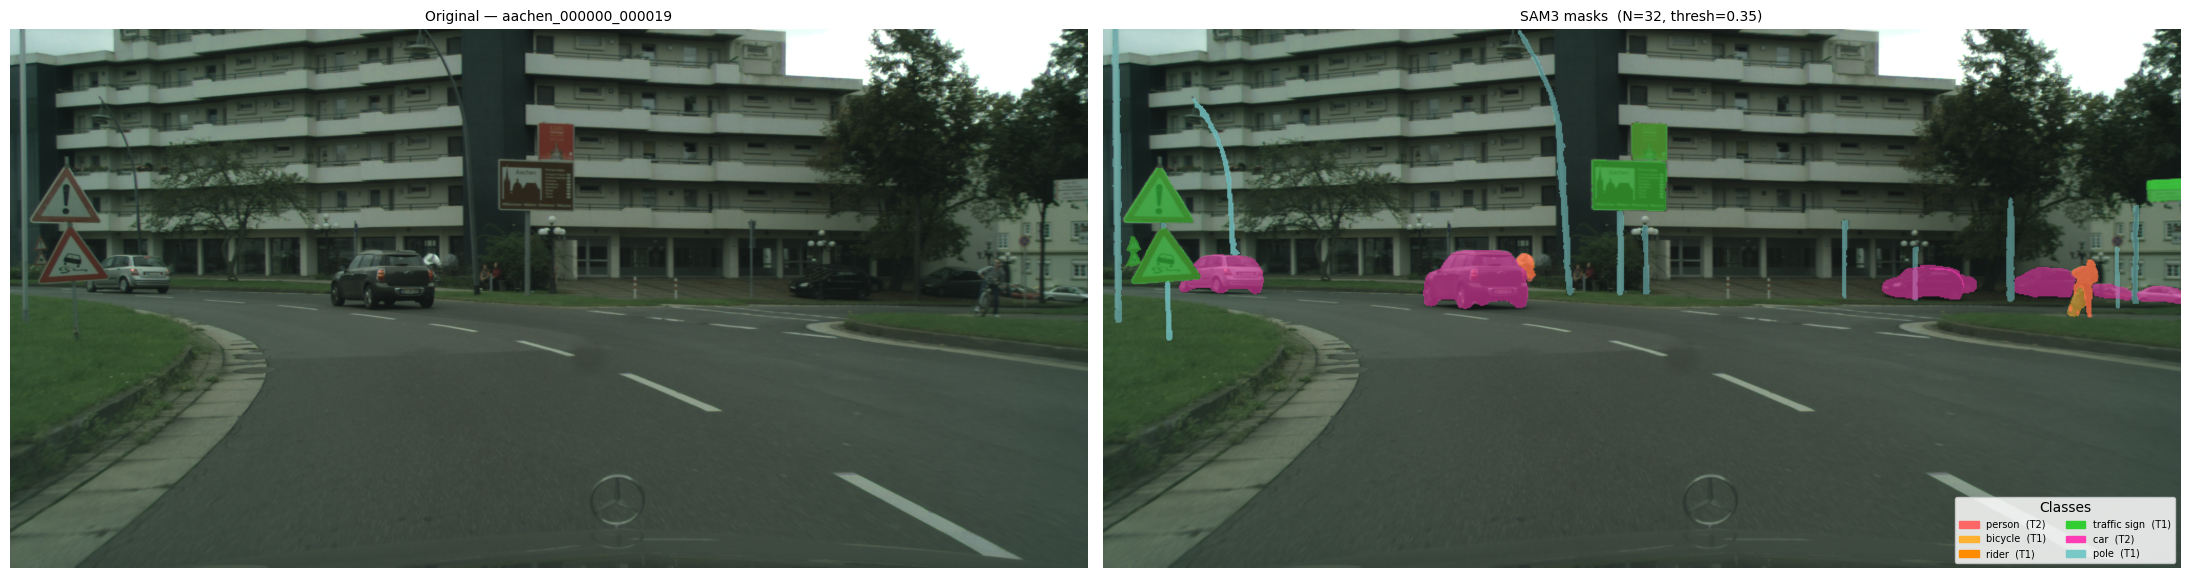

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
from PIL import Image

# ── Distinct color palette: one color per class (not per mask) ─────────────────
_CLASS_COLORS = {
    0:  (255, 102, 102),   # person        — salmon red
    1:  (255, 178,  50),   # bicycle       — amber
    2:  (255, 230,   0),   # motorcycle    — yellow
    3:  (255, 140,   0),   # rider         — orange
    4:  ( 50, 205,  50),   # traffic sign  — lime green
    5:  (  0, 180, 120),   # traffic light — teal
    6:  (  0, 160, 255),   # truck         — sky blue
    7:  (  0,  90, 200),   # bus           — deep blue
    8:  ( 80,  50, 200),   # train         — indigo
    9:  (160,  82,  45),   # guard rail    — sienna
    10: (200, 100, 200),   # caravan       — violet
    11: (180,  20, 180),   # trailer       — purple
    12: (255,  60, 180),   # car           — hot pink
    13: (120, 200, 200),   # pole          — aqua
}

ALPHA = 0.55   # mask opacity


def _load_npz_or_session(npz_path, session_arrays=None):
    """Load from disk if available, else use in-memory arrays from Cell 1."""
    if Path(npz_path).exists():
        d = np.load(str(npz_path), allow_pickle=False)
        return d["masks"].astype(bool), d["iou_scores"], d["areas"], \
               d.get("class_labels", np.full(len(d["masks"]), -1, dtype=np.int32))
    if session_arrays is not None:
        return session_arrays
    raise FileNotFoundError(f".npz not found and no session arrays provided: {npz_path}")


npz_path = Path(SAM_MASKS_DIR) / CITY / f"{STEM}_fine_masks.npz"
img_path = Path(CITYSCAPES_ROOT) / "leftImg8bit" / "train" / CITY / f"{STEM}_leftImg8bit.png"

image_pil = Image.open(img_path).convert("RGB")
masks, ious, areas, cls_labels = _load_npz_or_session(
    npz_path,
    session_arrays=(masks_arr, ious_arr, areas_arr, labels_arr),  # from Cell 1
)

# Resize masks to match original image resolution
orig_w, orig_h = image_pil.size
img_np = np.array(image_pil)
if masks.shape[0] > 0 and masks.shape[1:] != (orig_h, orig_w):
    resized = np.stack([
        np.array(Image.fromarray(m.astype(np.uint8) * 255).resize((orig_w, orig_h), Image.NEAREST)) > 127
        for m in masks
    ])
    masks = resized

# Build overlay
overlay = img_np.copy().astype(np.float32)
for i, m in enumerate(masks):
    color = np.array(_CLASS_COLORS.get(int(cls_labels[i]), (200, 200, 200)), dtype=np.float32)
    overlay[m] = overlay[m] * (1 - ALPHA) + color * ALPHA
overlay = overlay.clip(0, 255).astype(np.uint8)

# Legend patches
cls_in_image = sorted(set(int(c) for c in cls_labels))
patches = [
    mpatches.Patch(
        color=tuple(v / 255 for v in _CLASS_COLORS.get(c, (200, 200, 200))),
        label=f"{_IDX_TO_NAME.get(c, '?')}  (T{'1' if c in TIER1_IDX else '2'})"
    )
    for c in cls_in_image
]

fig, axes = plt.subplots(1, 2, figsize=(22, 7))
axes[0].imshow(img_np)
axes[0].set_title(f"Original — {STEM}", fontsize=10)
axes[0].axis("off")

axes[1].imshow(overlay)
axes[1].set_title(f"SAM3 masks  (N={len(masks)}, thresh={SAM3_SCORE_THRESH})", fontsize=10)
axes[1].axis("off")
axes[1].legend(handles=patches, loc="lower right", fontsize=7,
               framealpha=0.85, ncol=2, title="Classes")

plt.tight_layout()
plt.show()

---
## Cell 4 — Masks with labels annotated at centroids

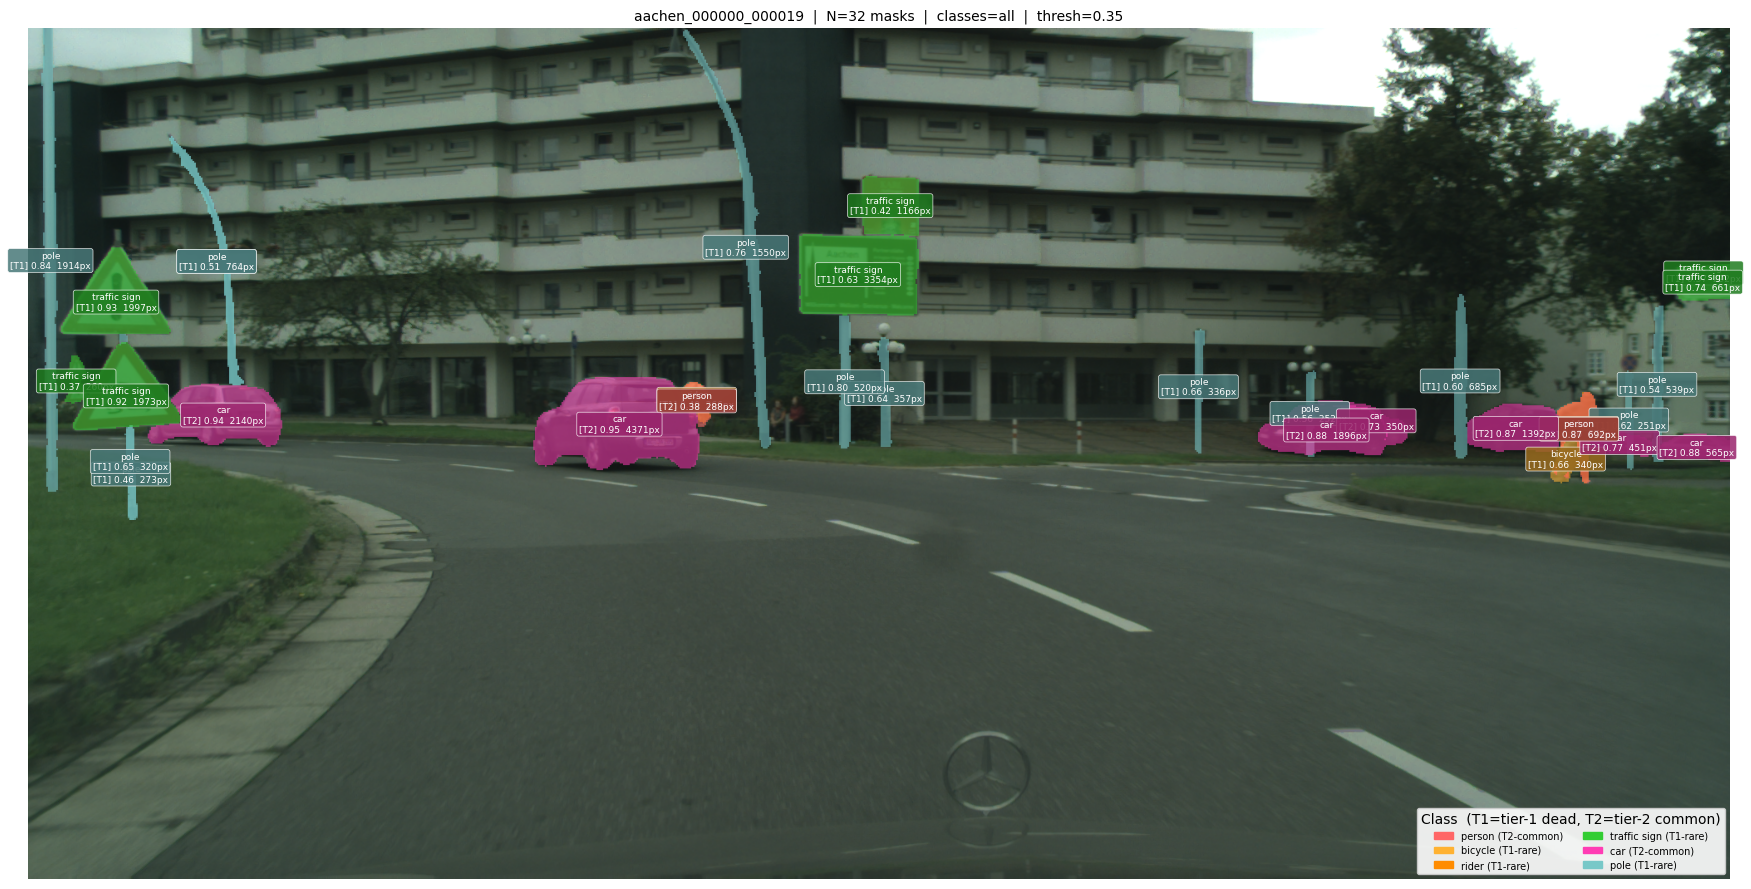

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
from PIL import Image

# ── Optional: filter to specific classes only ──────────────────────────────────
SHOW_CLASSES = None   # None = all; or e.g. [1, 2, 12] for bicycle, motorcycle, car
MIN_IOU_SHOW = 0.0    # additional quality filter for display (0 = show all)

npz_path = Path(SAM_MASKS_DIR) / CITY / f"{STEM}_fine_masks.npz"
img_path = Path(CITYSCAPES_ROOT) / "leftImg8bit" / "train" / CITY / f"{STEM}_leftImg8bit.png"

image_pil = Image.open(img_path).convert("RGB")
orig_w, orig_h = image_pil.size
img_np = np.array(image_pil)

masks, ious, areas, cls_labels = _load_npz_or_session(
    npz_path,
    session_arrays=(masks_arr, ious_arr, areas_arr, labels_arr),
)

# Resize masks if needed
if masks.shape[0] > 0 and masks.shape[1:] != (orig_h, orig_w):
    masks = np.stack([
        np.array(Image.fromarray(m.astype(np.uint8) * 255).resize((orig_w, orig_h), Image.NEAREST)) > 127
        for m in masks
    ])

# Build overlay with labels
overlay = img_np.copy().astype(np.float32)
fig, ax = plt.subplots(figsize=(22, 9))

label_positions = []   # (cx, cy, text) — stored to avoid overlap checks

for i, (m, iou, area, cls_idx) in enumerate(zip(masks, ious, areas, cls_labels)):
    cls_idx = int(cls_idx)
    if SHOW_CLASSES is not None and cls_idx not in SHOW_CLASSES:
        continue
    if float(iou) < MIN_IOU_SHOW:
        continue

    color = np.array(_CLASS_COLORS.get(cls_idx, (200, 200, 200)), dtype=np.float32)
    overlay[m] = overlay[m] * (1 - ALPHA) + color * ALPHA

    # Mask contour
    ys, xs = np.where(m)
    if len(ys) == 0:
        continue
    cy, cx = int(ys.mean()), int(xs.mean())

    # Tier badge
    tier = "T1" if cls_idx in TIER1_IDX else "T2"
    cls_name = _IDX_TO_NAME.get(cls_idx, f"cls{cls_idx}")
    label = f"{cls_name}\n[{tier}] {iou:.2f}  {area}px"
    label_positions.append((cx, cy, label, color / 255.0))

ax.imshow(overlay.clip(0, 255).astype(np.uint8))

for cx, cy, label, facecolor in label_positions:
    ax.text(
        cx, cy, label,
        color="white", fontsize=6.5, ha="center", va="center",
        bbox=dict(
            boxstyle="round,pad=0.25",
            fc=tuple(facecolor * 0.6),   # darker shade of class color
            ec="white", alpha=0.85, lw=0.5,
        ),
    )

# Title and legend
cls_in_image = sorted(set(int(c) for c in cls_labels
                          if (SHOW_CLASSES is None or int(c) in SHOW_CLASSES)))
patches = [
    mpatches.Patch(
        color=tuple(v / 255 for v in _CLASS_COLORS.get(c, (200, 200, 200))),
        label=f"{_IDX_TO_NAME.get(c,'?')} ({'T1-rare' if c in TIER1_IDX else 'T2-common'})"
    )
    for c in cls_in_image
]
ax.legend(handles=patches, loc="lower right", fontsize=7, framealpha=0.9,
          ncol=2, title="Class  (T1=tier-1 dead, T2=tier-2 common)")

show_cls_str = "all" if SHOW_CLASSES is None else str(SHOW_CLASSES)
ax.set_title(
    f"{STEM}  |  N={len(masks)} masks  |  classes={show_cls_str}  |  thresh={SAM3_SCORE_THRESH}",
    fontsize=10,
)
ax.axis("off")
plt.tight_layout()
plt.show()

---
## Cell 5 (Bonus) — Save the in-memory masks from Cell 1 to disk

In [6]:
out_dir = Path(SAM_MASKS_DIR) / CITY
out_dir.mkdir(parents=True, exist_ok=True)
out_path = out_dir / f"{STEM}_fine_masks.npz"

np.savez_compressed(
    str(out_path),
    masks=masks_arr,
    iou_scores=ious_arr,
    areas=areas_arr,
    class_labels=labels_arr,
)
print(f"Saved {len(masks_arr)} masks → {out_path}")

Saved 32 masks → /Users/qbit-glitch/Desktop/datasets/cityscapes/sam_fine_masks_sam3/train/aachen/aachen_000000_000019_fine_masks.npz
